<a href="https://colab.research.google.com/github/ErickCarlis/scouting-segmentacao-atletas-clusterizacao/blob/main/Identificando_Perfis_de_Atletas_com_Dataset_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scouting: Utilizando Machine Learning para Identificar Perfis de Atletas (Clustering) com o Dataset Wine

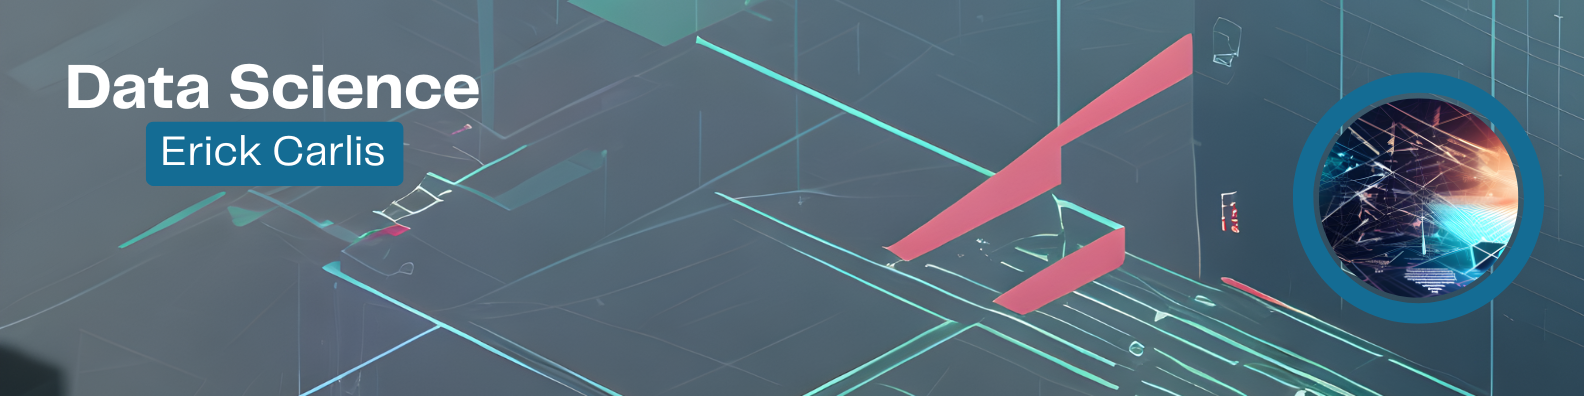

##O Clustering, vital para o Futebol moderno, é usado para:

###Identificar perfis de jogadores: Encontrar "jogadores similares" no mercado (o famoso "estilo Moneyball").

###Análise de Elenco: Agrupar atletas por carga de trabalho para personalizar treinos.

###Scouting: Descobrir talentos que têm números parecidos com estrelas mundiais, mas custam menos.

In [1]:
# Importando as bibliotecas
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

# Carregando os dados
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Como álcool e magnésio têm escalas diferentes, precisamos padronizar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("Dados carregados e padronizados")
print(f"Temos {df.shape[0]} 'jogadores' e {df.shape[1]} atributos técnicos.")

Dados carregados e padronizados
Temos 178 'jogadores' e 13 atributos técnicos.


####Embora o dataset se chame "Wine" (Vinho), fiz uma analogia de domínio. No link do Scikit-Learn, o dataset Wine contém 13 medidas químicas (álcool, magnésio, cor, etc.).

####Imaginando que cada 'vinho' é um jogador e cada 'medida química' é um atributo físico ou técnico (velocidade, passes certos, desarmes) utilizei o algoritmo K-Means para descobrir, sem intervenção humana, quantos grupos naturais de jogadores existem nesse elenco.

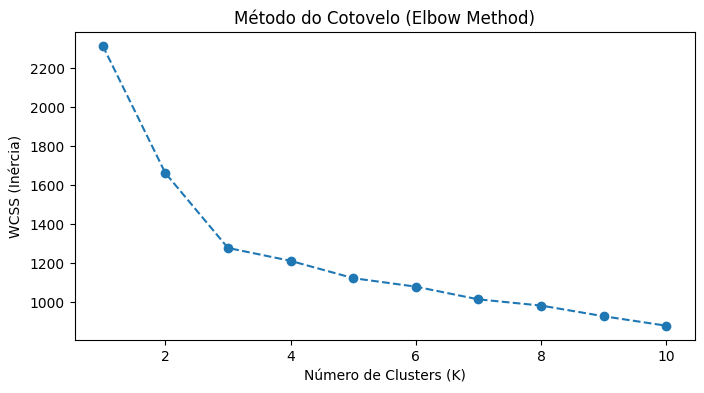

In [2]:
# Inércia (Within-Cluster Sum of Square)
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(df_scaled)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle="--")
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Inércia)')
plt.show()

##O que é esse "K"?
###Imagine que ao entrar em um vestiário com 180 jogadores desconhecidos, você não sabe quem é atacante, zagueiro ou goleiro.

####Se o K = 1, você trata todo mundo igual (possibilidade alta de erro).

####Se o K = 180, você cria um treino individual para cada um (possibilidade inviável).

####O K ideal (o "cotovelo") é o equilíbrio: o menor número de grupos que ainda explica bem as diferenças entre os sujeitos.

###No gráfico acima, o "ponto de equilíbrio" onde o ganho de informação deixa de ser drástico é o 3 (entre 2 e 4). Isso significa que, matematicamente, existem 3 perfis distintos de "jogadores" (vinhos) nesse conjunto de dados.

##Criando os Perfis (Treinando o K-Means)
###Agora que está definido $K=3$, o algoritmo irá rotular cada linha do DataFrame.

In [3]:
# Criando o modelo com 3 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(df_scaled)

# Adicionando a coluna de 'Perfil' ao DataFrame original
df['Perfil_Atleta'] = clusters

print("Atletas agrupados com sucesso!")
print(df['Perfil_Atleta'].value_counts())

Atletas agrupados com sucesso!
Perfil_Atleta
0    65
2    62
1    51
Name: count, dtype: int64


###Visualizando os Grupos (A "Foto" do Elenco)

####Com temos 13 colunas, não conseguimos ver um gráfico de 13 dimensões. O segredo foi escolher duas características marcantes para ver como os grupos se separam, utilizando alcohol (que no esporte pode ser Intensidade) e proline (que pode ser Força/Potência).

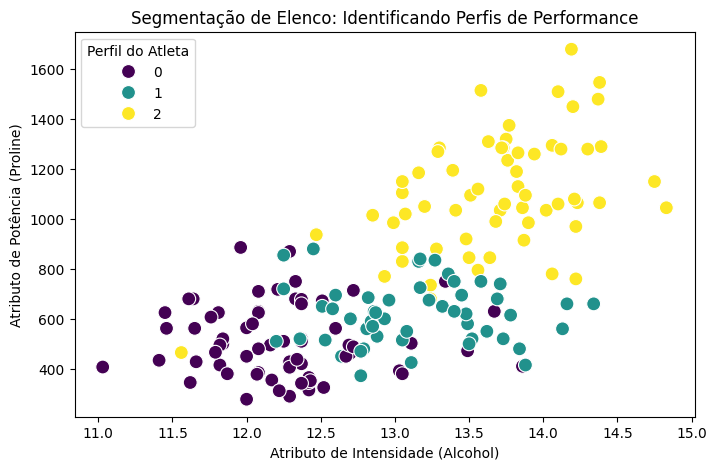

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='alcohol', y='proline', hue='Perfil_Atleta', palette='viridis', s=100)
plt.title('Segmentação de Elenco: Identificando Perfis de Performance')
plt.xlabel('Atributo de Intensidade (Alcohol)')
plt.ylabel('Atributo de Potência (Proline)')
plt.legend(title='Perfil do Atleta')
plt.show()

###Esses "pontinhos amarelos" são os "Atletas de Elite".

####Matematicamente, eles formam o grupo de alta performance: alta intensidade combinada com alta potência. No futebol, esse seria o perfil de um "Box-to-Box" ou um atacante explosivo que mantém a intensidade o jogo todo.

In [5]:
# Analisando a média de cada perfil
analise_perfis = df.groupby('Perfil_Atleta').mean()
print(analise_perfis[['alcohol', 'proline', 'magnesium']])

                 alcohol      proline   magnesium
Perfil_Atleta                                    
0              12.250923   510.169231   92.738462
1              13.134118   619.058824   98.666667
2              13.676774  1100.225806  107.967742


####O grupo com Alcohol alto e Proline alta pode ser o "Perfil de Elite/Alta Intensidade".

####O grupo com Magnesium alto pode ser um perfil com outra característica física predominante.

###Vamos ao resumo visual do que define cada um dos 3 grupos.

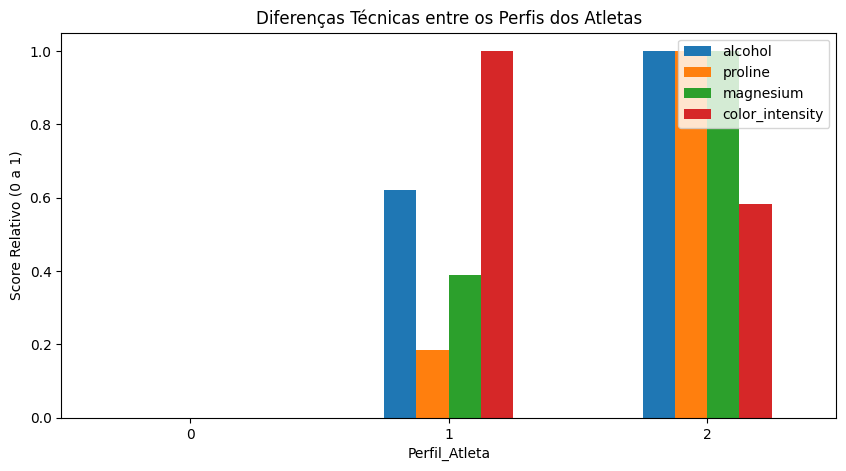

In [6]:
# Preparando os dados para um gráfico de barras comparativo
perfil_resumo = df.groupby('Perfil_Atleta')[['alcohol', 'proline', 'magnesium', 'color_intensity']].mean()

#Normalizando no gráfico para que todos fiquem na mesma escala de visualização
perfil_resumo_norm = (perfil_resumo - perfil_resumo.min()) / (perfil_resumo.max() - perfil_resumo.min())

perfil_resumo_norm.plot(kind='bar', figsize=(10, 5))
plt.title('Diferenças Técnicas entre os Perfis dos Atletas')
plt.ylabel('Score Relativo (0 a 1)')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

####Perfil Amarelo (Elite): Atletas de Alta Intensidade e Explosão.

####Perfil Roxo/Verde (Resistência): Atletas de Equilíbrio Tático (médias mais constantes).

####Perfil de Suporte: Atletas com foco em Atributos Técnicos Específicos (onde o magnésio ou cor se destacam).

#Conclusão


###Não basta ter os dados, é preciso saber quem é quem no elenco.

###Neste projeto, utilizei Aprendizado Não Supervisionado (K-Means) para segmentar um banco de dados de performance. Ao aplicar o Método do Cotovelo, identifiquei 3 perfis distintos de atletas.

###Não Supervisionado: Eu não disse ao computador quem era quem; o algoritmo encontrou os padrões sozinho.

###Otimização: Utilizei o Método do Cotovelo para garantir que a segmentação fosse matematicamente justa.

###Aplicação no Futebol: Essa técnica permite que clubes identifiquem 'clones' de jogadores ou organizem treinos específicos para grupos com necessidades fisiológicas similares.

###Essa técnica é a base para o Scouting Moderno: permite encontrar jogadores com características similares (o famoso 'Replacement Analysis') e personalizar cargas de treino para cada grupo, otimizando a performance e prevenindo o desgaste.